### Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn
from tensorflow import keras
from sklearn.model_selection import train_test_split
%matplotlib inline

In [ ]:
# # In case of errors, check if you are using the correct versions of the libraries. This notebook works on the following versions of libraries. Specify these versions if you get version related errors.
# TensorFlow version: 2.17.0
# Pandas version: 2.2.2
# NumPy version: 1.26.4
# Scikit-learn version: 1.5.2
# Keras version: 3.4.1

# print("TensorFlow version:", tf.__version__)
# print("Pandas version:", pd.__version__)
# print("NumPy version:", np.__version__)
# print("Scikit-learn version:", sklearn.__version__)
# print("Keras version:", tf.keras.__version__)

### Loading data

In [6]:
!unzip MNIST_data.zip
!ls

Archive:  MNIST_data.zip
  inflating: test.csv                
  inflating: train.csv               
MNIST_data.zip	sample_data  test.csv  train.csv


In [1]:
data = pd.read_csv('./data/train.csv')
X_test = pd.read_csv("./data/test.csv")

NameError: name 'pd' is not defined

In [8]:
data.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Extracting feature variables and target variable

In [9]:
data_y = data['label'].values
data_x = data.drop('label',axis=1)

In [10]:
data_x.head(2)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Data visualization

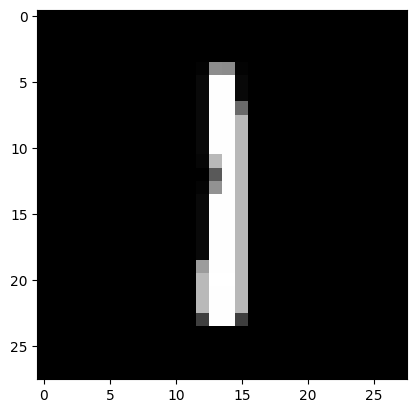

In [11]:
img = data_x.iloc[2].values.reshape((28,28))
plt.imshow(img,cmap='gray')

In [12]:
set(data_y)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [13]:
X_train, X_val, y_train, y_val = train_test_split(data_x, data_y, test_size = 0.1, random_state=42)

### Model Building


<div><span><p>The choice of 128 neurons for the hidden layers (2nd to 4th in this case) is a common practice in neural network design, but it's not a hard rule. It's considered a <em>hyperparameter</em> that often needs to be determined through experimentation and validation.</p>
<p>Here's why such a number might be chosen and how it's typically determined:</p>
<ol>
<li><p><strong>Heuristics and Common Practice:</strong> Many introductory examples and successful models in tasks like image classification (which MNIST is) use powers of 2 for neuron counts (e.g., 32, 64, 128, 256, 512). 128 is a reasonable starting point that offers enough capacity to learn complex patterns without being excessively large for this dataset.</p>
</li>
<li><p><strong>Model Capacity:</strong> The number of neurons directly influences the model's capacity to learn intricate relationships in the data. Too few neurons might lead to an <em>underfitting</em> model (unable to capture the underlying patterns), while too many can lead to <em>overfitting</em> (memorizing the training data but performing poorly on unseen data).</p>
</li>
<li><p><strong>Computational Cost:</strong> More neurons mean more parameters, which in turn means more computational resources (memory and processing power) and longer training times. For a relatively small dataset like MNIST, 128 neurons per layer is a good balance.</p>
</li>
<li><p><strong>Trial and Error (Hyperparameter Tuning):</strong> In a real-world scenario, you would typically experiment with different numbers of neurons (e.g., 64, 128, 256) and evaluate the model's performance on a validation set. Techniques like grid search, random search, or more advanced methods like Bayesian optimization are used to find the optimal set of hyperparameters, including the number of neurons and layers.</p>
</li>
</ol>
<p>In essence, for this specific problem, 128 neurons per layer likely provides a good balance between model complexity, learning capacity, and computational efficiency, often found through prior experience or basic hyperparameter tuning experiments.</p>
</span></div>

In [17]:
# model = keras.Sequential([
#     keras.layers.Dense(128, activation=tf.nn.relu, input_shape=(784,)),
#     keras.layers.Dense(128, activation=tf.nn.relu),
#     keras.layers.Dense(128, activation=tf.nn.relu),
#     keras.layers.Dense(10, activation=tf.nn.softmax)])

# Newer versions of Keras support this:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)])

In [18]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

### Model training

In [19]:
model.fit(X_train, y_train, batch_size=64, epochs=5, validation_data=(X_val, y_val))

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7629 - loss: 5.5944 - val_accuracy: 0.8933 - val_loss: 0.6175
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9247 - loss: 0.3884 - val_accuracy: 0.9236 - val_loss: 0.3980
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9461 - loss: 0.2137 - val_accuracy: 0.9343 - val_loss: 0.3009
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9571 - loss: 0.1555 - val_accuracy: 0.9429 - val_loss: 0.2739
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9628 - loss: 0.1404 - val_accuracy: 0.9405 - val_loss: 0.3027


### Model evaluation

In [20]:
model.predict(X_test).argmax(axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([2, 0, 9, ..., 3, 9, 2])

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
The predicted label is: 0


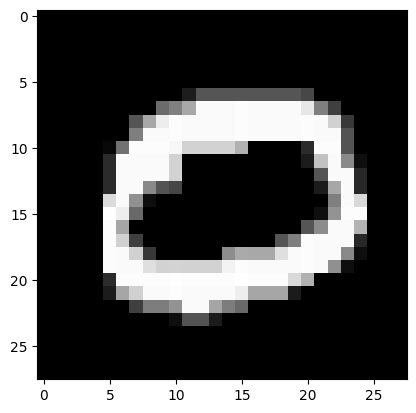

In [21]:
img = X_test.iloc[1].values.reshape((28,28))
plt.imshow(img,cmap='gray')
print("The predicted label is:" ,model.predict(X_test).argmax(axis=1)[1])

Further ahead: You can try increasing the model layers and play with the hyperparameters to increase model's performance

<div class="MuiBox-root css-1bi8ut6"><div class="text_component" data-testid="text-component"><p>A visualisation of the model architecture used for training the neural network for the MNIST data set is given below.</p><p>&nbsp;</p><p><img data-width="997" data-height="493" height="296.6900702106319" width="600" src="https://images.upgrad.com/acfaa76b-057f-4ec7-aac7-2bf5c0c4eb0b-N data.jpg"></p><p>&nbsp;</p><p dir="ltr">Now, you know how to use Keras to build and train neural networks. You may want to change the values of different hyperparameters in the model and analyse how it affects model performance.&nbsp;</p><p dir="ltr">&nbsp;</p><p dir="ltr"><strong>In the next segment</strong>, we will discuss different modifications that can be done to build better neural networks.&nbsp;</p></div></div>

# Epoch, Batch, Overfitting and Underfitting

<div class="text_component" data-testid="online-editor-content"><p dir="ltr">In the previous segment, you learnt how to write the code snippets for building and training a neural network using Keras. You saw its implementations on two different examples and understood the meaning behind each line of code while <strong>building</strong> the model. In this segment, we will discuss different attributes such as batch and epoch in depth. We will also discuss the different aspects of the output summary obtained from the network.&nbsp;</p><p>&nbsp;</p><p dir="ltr">Let’s concentrate on what we had done while building the ANN for MNIST. We built a full-fledged classification architecture. Let’s now start analysing the main elements of the architecture other than the parameters of the architecture. These elements are called <strong>hyperparameters</strong>.<b>&nbsp;</b></p><p>&nbsp;</p><p dir="ltr">Let’s start with the term ‘<strong>epochs</strong>’. In the following line of code, a model is being trained using the function fit(). A number of arguments are passed to this function which we have seen earlier. We will concentrate on the ‘epochs’ argument first:&nbsp;</p><pre>model.fit(X_train, y_train, batch_size=64, epochs=5, validation_data=(X_val, y_val))
</pre><p>&nbsp;</p><p dir="ltr">The number of <strong>epochs </strong>mentioned in the code snippet defines the number of times the learning algorithm will work through the entire data set. One epoch indicates that each training example has had an opportunity to update the internal model parameters, i.e., the weights and biases.</p><p>&nbsp;</p><p dir="ltr">Now, lets consider the batch size hyperparameter represented by the argument ‘batch_size’ in the following line of code:</p><pre>model.fit(X_train, y_train, batch_size=64, epochs=5, validation_data=(X_val, y_val))
</pre><p>&nbsp;</p><p dir="ltr"><strong>Batch size</strong> refers to the number of training examples utilised in one iteration. The model decides the number of examples to work with in each iteration before updating the internal model parameters.</p><p dir="ltr">A <strong>model summary</strong> states the details of the parameters used and displays the layers of the architecture. A simple summary() function is required for this:</p><p>&nbsp;</p><pre>model.summary()
</pre><p>&nbsp;</p><p dir="ltr">This can be used after we compile the model (refer to the previous segment for more details on this). For the MNIST architecture, we have the summary given below.</p><div id="code-snippet-cke_11431" data-lang="python" class="code-snippet-container"><div contenteditable="false" class="code"><pre style="margin: 0; line-height: 125%;"><span></span><span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> ETA: <span style="color: #0000DD; font-weight: bold">0</span>s <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">1.6376</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.8366</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">7</span>s <span style="color: #0000DD; font-weight: bold">7</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">1.6376</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.8366</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.4750</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.8967</span>
Epoch <span style="color: #0000DD; font-weight: bold">2</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">5</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">4</span>s <span style="color: #0000DD; font-weight: bold">7</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">0.3136</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.9265</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.3424</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.9255</span>
Epoch <span style="color: #0000DD; font-weight: bold">3</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">5</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">4</span>s <span style="color: #0000DD; font-weight: bold">6</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">0.2075</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.9460</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.3897</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.9140</span>
Epoch <span style="color: #0000DD; font-weight: bold">4</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">5</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">4</span>s <span style="color: #0000DD; font-weight: bold">6</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">0.1615</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.9563</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.2382</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.9479</span>
Epoch <span style="color: #0000DD; font-weight: bold">5</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">5</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">4</span>s <span style="color: #0000DD; font-weight: bold">6</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">0.1431</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.9599</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.2876</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.9343</span>
</pre></div></div><p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p><p dir="ltr"><strong>Some important points regarding this model summary are as follows:</strong></p><ol><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">The<strong> model is given as ‘sequential’</strong>, which means that the layers are set up one after the other in a singular sequence.</p></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">We know the <strong>input data’s size is 784</strong>, which means that 784 neurons are present in the input layer.</p></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">The first hidden layer is a <strong>dense layer</strong>, which means that all of its neurons are fully connected with the neurons of the previous layer, which is the input layer. The output shape is defined as 128, which means that the hidden layer has 128 neurons.</p>The number of parameters is as follows:<ol><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">If the input layer has 784 neurons and the first hidden layer has 128 neurons and is fully connected (dense), then the weight matrix will be of size 784 x 128, and there will be 128 elements in the bias vector, one for each neuron in the hidden layer.</p></li><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">Total elements in the weight matrix = 784 x 128 = 100352</p></li><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">Total elements in the bias vector = 128</p></li><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">Total number of parameters&nbsp; = 100352 + 128 = 100480 (as is given)</p></li></ol></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">The second hidden layer is a dense layer and has 128 neurons.</p>The number of parameters is as follows:<ol><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">If the first hidden layer has 128 neurons and the second hidden layer has 128 neurons, then the weight matrix is of size 128 x 128 and the bias vector is of size 128.</p></li><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">Total elements in the weight matrix = 128 x 128 = 16384</p></li><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">Total elements in the bias vector = 128</p></li><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">Total number of parameters = 16384 + 128 = 16512 (as is given)</p></li></ol></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">Similarly, the third hidden layer is dense and has 128 neurons. Since the second hidden layer has 128 neurons too, the total number of parameters will be 16512 (just as described in the previous point).</p></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">The last dense layer is the output layer with 10 neurons (classes).&nbsp;</p>The number of parameters is as follows:<ol><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">The third hidden layer has 128 neurons, and the output layer has 10 neurons. The weight matrix is of size 128 x 10 and the bias vector is of size 10.&nbsp;</p></li><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">Total elements in the weight matrix = 128 x 10 = 1280</p></li><li dir="ltr" aria-level="3"><p dir="ltr" role="presentation">Total number of parameters = 1280 + 10 = 1290 (as is given)</p></li></ol></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">In the end, the summary shows the <strong>total of trainable and non-trainable parameters</strong>. Trainable parameters are the ones going through the learning process, i.e., the weights and biases. Non-trainable parameters are the ones that do not go through the training process. For example in the following code, ‘0.3’ defines the number of randomly selected weights set to zero, and this is not going to change throughout the training process.</p><pre>keras.layers.Dropout(0.3)
</pre><p>Hence, it is a non-trainable parameter. (Note: You will learn about Dropouts shortly.)</p></li></ol><p>&nbsp;</p><p dir="ltr">So far, only weights and biases and no other types of parameters are included in this model; hence, all the parameters are trainable parameters.&nbsp;<strong>This gives us the&nbsp;sum of all the parameters in all the layers as 134794.</strong></p><p dir="ltr">&nbsp;</p><p dir="ltr">While training the model after using <strong>model.fit()&nbsp;</strong>function, you must have seen something like this:</p><div id="code-snippet-cke_11430" data-lang="python" class="code-snippet-container"><div contenteditable="false" class="code"><pre style="margin: 0; line-height: 125%;"><span></span><span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> ETA: <span style="color: #0000DD; font-weight: bold">0</span>s <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">1.6376</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.8366</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">7</span>s <span style="color: #0000DD; font-weight: bold">7</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">1.6376</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.8366</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.4750</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.8967</span>
Epoch <span style="color: #0000DD; font-weight: bold">2</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">5</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">4</span>s <span style="color: #0000DD; font-weight: bold">7</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">0.3136</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.9265</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.3424</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.9255</span>
Epoch <span style="color: #0000DD; font-weight: bold">3</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">5</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">4</span>s <span style="color: #0000DD; font-weight: bold">6</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">0.2075</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.9460</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.3897</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.9140</span>
Epoch <span style="color: #0000DD; font-weight: bold">4</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">5</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">4</span>s <span style="color: #0000DD; font-weight: bold">6</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">0.1615</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.9563</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.2382</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.9479</span>
Epoch <span style="color: #0000DD; font-weight: bold">5</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">5</span>
<span style="color: #0000DD; font-weight: bold">591</span><span style="color: #333333">/</span><span style="color: #0000DD; font-weight: bold">591</span> [<span style="color: #333333">==============================</span>] <span style="color: #333333">-</span> <span style="color: #0000DD; font-weight: bold">4</span>s <span style="color: #0000DD; font-weight: bold">6</span>ms<span style="color: #333333">/</span>step <span style="color: #333333">-</span> loss: <span style="color: #6600EE; font-weight: bold">0.1431</span> <span style="color: #333333">-</span> accuracy: <span style="color: #6600EE; font-weight: bold">0.9599</span> <span style="color: #333333">-</span> val_loss: <span style="color: #6600EE; font-weight: bold">0.2876</span> <span style="color: #333333">-</span> val_accuracy: <span style="color: #6600EE; font-weight: bold">0.9343</span>
</pre></div></div><p>&nbsp;</p><p>&nbsp;</p><p><strong>The text above can be analysed as follows:</strong>&nbsp;</p><ol><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">The<strong> text 591/591 indicates the number of batches </strong>the training step is running through. Since the batch size is 64 and the training data set is of size 37800 (90% of the total&nbsp; dataset which is 42000) while the rest 10% is validation dataset, it will be separated into 591 batches (37800/64).</p></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">You can also see the amount of time it is taking for training a single batch, for example, 7ms/step.</p></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">The text snippets <em>loss </em>and <em>val_loss</em> show the sparse categorical cross-entropy loss (mentioned while compiling the model; refer to the previous segment for this).</p></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">The text snippets <em>accuracy</em> and <em>val_accuracy</em> show the proportion of matches between the predicted class and the actual class. This proportion is calculated on the whole training and validation data sets.</p></li><li dir="ltr" aria-level="1"><p dir="ltr" role="presentation">And, after 5 epochs (5 run-throughs of training the whole data set), we can see the validation accuracy reached is approximately 93%.</p></li></ol><p dir="ltr" role="presentation"><strong>Note</strong>: The calculation speed, loss, and accuracy may differ slightly in each runtime as it depends on computational power.</p><p dir="ltr" role="presentation">&nbsp;</p><p dir="ltr">There are two points to keep in mind regarding training a model on a data set. Firstly, the model should be able to determine generalised trends in a proper manner for smarter predictions. Secondly, it should be able to apply these observations and trends to future data (the data that the model has never seen) and make predictions accurately. To measure how it is performing on these two bases, we assess whether the model may be overfitting or underfitting. If the model overfits, it will perform well on the training data set, but not on the testing data set. If the model underfits, it will find it difficult to identify even the major patterns present in the data.</p><p dir="ltr">&nbsp;</p><p dir="ltr">If the model is not able to understand the underlying trend of the given data set, then the model is said to be <strong>underfitting</strong>. And, the accuracy of the model is low even on the training data set. This usually happens when the amount of data to train on is less or the model defined has linear elements with few non-linear relationships for it to be able to understand complex trends and patterns. When this happens, the model becomes more free and flexible, which results in incorrect predictions even on the training data. The opposite is true when the model overfits, that is, the model learns the exact patterns of the training data and is unable to generalise on unseen data. Both underfitting and overfitting are issues that needs to be addressed.</p><p dir="ltr">&nbsp;</p><p>To summarise, you have understood what different aspects of the model output mean when training the model after we have defined the model architecture and hyperparameters.<strong> </strong></p><p>The training process requires your careful attention to ensure that the model is learning well, not too much or not too less, and is able to observe underlying trends and patterns for making more accurate predictions on future data.</p><p>In the next segment, we will discuss the concept of dropouts, which is one way to regularise a neural network and handle overfitting.</p></div>